# Umbrella Sampling Example

In this notebook we will progressively populate the windows of an Umbrella Sampling simulation starting from a starting configuration in a metastable state.
For our example we will use capped alanine dipeptide and sample along the ψ dihedral, but it should be easy enough to adopt this example to other molecular systems and sampling coordinates.

In [1]:
%matplotlib inline

In [2]:
import asyncio
import os
import matplotlib.pyplot as plt
import numpy as np
from collections import abc

import asyncmd
import asyncmd.gromacs
import asyncmd.trajectory

Could not initialize SLURM cluster handling. If you are sure SLURM (sinfo/sacct/etc) is available try calling `asyncmd.config.set_all_slurm_settings()` or `asyncmd.config.set_slurm_setting()` with the appropriate arguments.


## Define a class to handle the Umbrella Sampling for each window

It will take care of running the simulation of a single US window.
We will pass it a coroutine function at initialization that will provide the seed trajectories, i.e. the trajectories from which it will select the initial configuration, as soon as said trajectories are ready.
This enables us to successively setup the windows by running each window for a shortish time (`n_steps_initial`) and then use the resulting trajectories to seed the neighboring window.

In [3]:
class UmbrellaSamplingWindow:
    def __init__(self, window_center: float,
                 seed_trajectories_generator: abc.Callable[[], abc.Awaitable[list[asyncmd.Trajectory]]],
                 workdir: str,
                 # we expect this to be a wrapped CV returning an 1d-array of shape (len(traj),)
                 #progress_cv: asyncmd.trajectory.functionwrapper.TrajectoryFunctionWrapper,
                 # but in fact it can be any awaitable that returns a 1d-numpy-array and takes an asyncmd.Trajectory
                 progress_cv: abc.Callable[[asyncmd.Trajectory], abc.Awaitable[np.typing.NDArray]],
                 n_steps_initial: int, n_steps_total: int,
                 engine_cls: type[asyncmd.gromacs.GmxEngine],
                 engine_kwargs: dict, walltime_per_part: float,
                 ):
        assert n_steps_initial <= n_steps_total
        self.window_center = window_center
        self.seed_trajectories_generator = seed_trajectories_generator
        self.workdir = workdir
        self.progress_cv = progress_cv
        self.n_steps_initial = n_steps_initial
        self.n_steps_total = n_steps_total
        self._first_trajectories = None
        self._all_trajectories = None
        self._propagator = asyncmd.trajectory.InPartsTrajectoryPropagator(
                                            n_steps=self.n_steps_initial,
                                            engine_cls=engine_cls,
                                            engine_kwargs=engine_kwargs,
                                            walltime_per_part=walltime_per_part,
                                            )

    async def await_first_trajectories(self):
        while self._first_trajectories is None:
            await asyncio.sleep(10)
        return self._first_trajectories

    async def generate_first_trajectories(self):
        # return the first trajectories running for n_steps_initial steps
        if self._first_trajectories is not None:
            return self._first_trajectories
        initial_conf = await self._get_initial_conf()
        print(f"Window at {self.window_center}: Initial configuration written.")
        trajectories = await self._propagator.propagate(
                                            starting_configuration=initial_conf,
                                            workdir=self.workdir,
                                            deffnm="us",
                                            )
        print(f"Window at {self.window_center}: First trajectories done.")
        self._first_trajectories = trajectories
        return trajectories

    async def _get_initial_conf(self):
        # wait for seed trajectories, then find conf closest to window center,
        # write this initial conf to workdir and return it
        seed_trajs = await self.seed_trajectories_generator()
        extractor = asyncmd.trajectory.convert.NoModificationFrameExtractor()
        # Iterate over all seed trajectories to find the configuration with minimal
        # distance to the window center
        all_cv_vals = await asyncio.gather(*(self.progress_cv(t) for t in seed_trajs))
        min_traj_idx = 0
        min_dist = None
        for traj_idx, cv_vals in enumerate(all_cv_vals):
            dists = (cv_vals - self.window_center)**2
            if min_dist is None or (np.min(dists) <= min_dist):
                idx = np.argmin(dists)
                min_dist = dists[idx]
                min_traj_idx = traj_idx
        # extract the configuration
        window_start_conf = await extractor.extract_async(
                                # TODO/FIXME: this is the only point where we assume gromacs engine
                                outfile=os.path.join(self.workdir, "window_start.trr"),
                                traj_in=seed_trajs[min_traj_idx],
                                idx=idx,
                                )
        return window_start_conf

    async def generate_trajectories(self):
        # return all trajectories by first doing the "first_trajectories", then
        # reset the propagator to n_steps_total and finally run until it is done
        if self._all_trajectories is not None:
            return self._all_trajectories
        if self._first_trajectories is None:
            await self.generate_first_trajectories()
        # first reset the number of steps!
        self._propagator.n_steps = self.n_steps_total
        # little hack to enable restart/continuation with new number of steps
        trajectories = await self._propagator.propagate(starting_configuration=None,
                                                        workdir=self.workdir,
                                                        deffnm="us",
                                                        continuation=True,
                                                        )
        print(f"Window at {self.window_center}: All trajectories done.")
        self._all_trajectories = trajectories
        return trajectories


## Setup the progress coordinate ψ

We will use the predefined collective variable function for the ψ and φ dihedrals of capped alanine dipeptide that is included with the example notebooks.

In [4]:
# import the descriptor function
cwd = os.path.abspath(os.getcwd())
# chdir to the resources folder so we can import the function
os.chdir("../resources/")
from ala_cv_funcs import descriptor_func_psi_phi
os.chdir(cwd)  # change back to the initial directory
# and wrap it
psi_phi_wrapped = asyncmd.trajectory.PyTrajectoryFunctionWrapper(descriptor_func_psi_phi)

async def psi_wrapped(traj):
    # we only need psi and we want a 1d-array
    # also we want it in degree and not radians
    deg = 180/np.pi
    return (await psi_phi_wrapped(traj))[:, 0] * deg


## Set simulation parameters (workdir, number of steps, window centers, MD engine parameters)

In [ ]:
#TODO: set this to a convenient path
workdir = "."
nsteps_initial = 10000  # 20 ps since dt = 2 fs
nsteps_total = 20 * nsteps_initial

# Define windows along progress coordinate (the psi-angle of ala)
# state alpha_R: -50 degree < psi < 30 degree
# state C7_eq: 120 degree < psi < 200 degree
# Note that window_centers must be an ordered list of floats,
# starting with the window closest to the initial configuration(s)
window_centers = [30, 60, 90, 120]

# Engine definition
# Note that we create and add the mdconfig object for each window separately below.
# There we directly set the correct window center values for the pull-code and more.
engine_kwargs_base = {"gro_file": "../resources/gromacs/capped_alanine_dipeptide/conf.gro",
                      "top_file": "../resources/gromacs/capped_alanine_dipeptide/topol_amber99sbildn.top",
                      "ndx_file": "../resources/gromacs/capped_alanine_dipeptide/index.ndx",
                      "mdrun_extra_args": "-nt 2",
                      "output_traj_type": "XTC",
                      }
mdconfig_file = "../resources/gromacs/capped_alanine_dipeptide/md.mdp"
engine_cls = asyncmd.gromacs.GmxEngine
walltime_per_part = 1/(600)  # 10 s expressed in units of hours


## Load the initial configuration(s)

In [6]:
# Define initial configuration (we just use a configuration in alpha_R)
# Note that this somewhat weird function mirrors what we will/would get from
# UmbrellaSamplingWindow.await_first_trajectories and what the UmbrellaSamplingWindow
# expects as seed_trajectory_generator: a coroutine function that returns a list
# of trajectories.
# We will use this function to initialize the first of our UmbrellaSamplingWindows.
async def get_initial_confs():
    return [asyncmd.Trajectory(
                trajectory_files="../resources/gromacs/capped_alanine_dipeptide/conf_in_alphaR.trr",
                structure_file="../resources/gromacs/capped_alanine_dipeptide/conf.gro",
                )
            ]

## Setup the UmbrellaSamplingWindow objects

In [7]:
# loop over window centers: setup pull-code in mdp,
# each window gets the first_trajectories of the previous window via seed_traj_gen,
# we put the initialized UmbrellaSamplingWindow objects into the windows list
windows: list[UmbrellaSamplingWindow] = []
# setup for the first window (we need a function to "generate" the seed trajectories for it too)
seed_traj_gen = get_initial_confs
for wc in window_centers:
    # prepare the mdp (and the engine_kwargs containing it) with the correct window center
    engine_kwargs = engine_kwargs_base.copy()
    mdconfig = asyncmd.gromacs.MDP(mdconfig_file)  # load our standard mdp file
    # setup gromacs pull-code for the current window
    mdconfig["pull"] = "yes"
    mdconfig["pull-nstxout"] = 1000
    mdconfig["pull-nstfout"] = 1000
    mdconfig["pull-ngroups"] = 4  # we have 4 atoms/groups per dihedral
    mdconfig["pull-ncoords"] = 1  # we build 1 pull coord from the 4 groups
    # our 4 atoms defining the ψ dihedral
    mdconfig["pull-group1-name"] = "psi_at1"
    mdconfig["pull-group2-name"] = "psi_at2"
    mdconfig["pull-group3-name"] = "psi_at3"
    mdconfig["pull-group4-name"] = "psi_at4"
    mdconfig["pull-coord1-type"] = "umbrella"  # make it a harmonic potential
    mdconfig["pull-coord1-geometry"] = "dihedral"  # around the dihedral
    mdconfig["pull-coord1-groups"] = ["1", "2", "2", "3", "3", "4"]  # defined by our 4 atoms
    # Note: the force-constant stiffness determines the possible window spacing,
    # i.e. the higher the force constant the closer the window centers must be
    # to result in overlap between the windows
    mdconfig["pull-coord1-k"] = "110"  # force constant in kJ/ (mol * rad**2)
    mdconfig["pull-coord1-init"] = round(wc, 2) # reference angle in degree
    # IMPORTANT: We set gen-vel=yes because we use a no-modification frame extractor
    mdconfig["gen-vel"] = "yes"
    # and finally set the output frequencies
    mdconfig["nstxout-compressed"] = mdconfig["nstlog"] = 100  # write XTC and log
    mdconfig["nstxout"] = mdconfig["nstvout"] = mdconfig["nstfout"] = 0  # disable TRR
    engine_kwargs["mdconfig"] = mdconfig
    # make sure the workdir for this window exists
    window_workdir = os.path.join(workdir, f"window_center_{round(wc, 2)}")
    os.makedirs(window_workdir, exist_ok=True)
    # now initialize the window object
    us_window = UmbrellaSamplingWindow(
                        window_center=wc,
                        seed_trajectories_generator=seed_traj_gen,
                        workdir=window_workdir,
                        progress_cv=psi_wrapped,
                        n_steps_initial=nsteps_initial,
                        n_steps_total=nsteps_total,
                        engine_cls=engine_cls,
                        engine_kwargs=engine_kwargs,
                        walltime_per_part=walltime_per_part,
                        )
    windows += [us_window]
    seed_traj_gen = us_window.await_first_trajectories


## Run all Umbrella Sampling windows at once

Due to the way we have defined the dependencies in the above cell this will successively populate the windows and run them all until they reach `n_steps_total` steps in each window.

In [8]:
all_trajectories = await asyncio.gather(*(w.generate_trajectories() for w in windows))

Window at 30: Initial configuration written.
Window at 30: First trajectories done.
Window at 60: Initial configuration written.
Window at 60: First trajectories done.
Window at 90: Initial configuration written.
Window at 90: First trajectories done.
Window at 120: Initial configuration written.
Window at 120: First trajectories done.
Window at 30: All trajectories done.
Window at 60: All trajectories done.
Window at 90: All trajectories done.
Window at 120: All trajectories done.


## Analyze/plot the generated trajectories

In [9]:
all_psi_phi_values = []

for trajs_for_window in all_trajectories:
    all_psi_phi_values += [await asyncio.gather(*(psi_phi_wrapped(traj) for traj in trajs_for_window))]

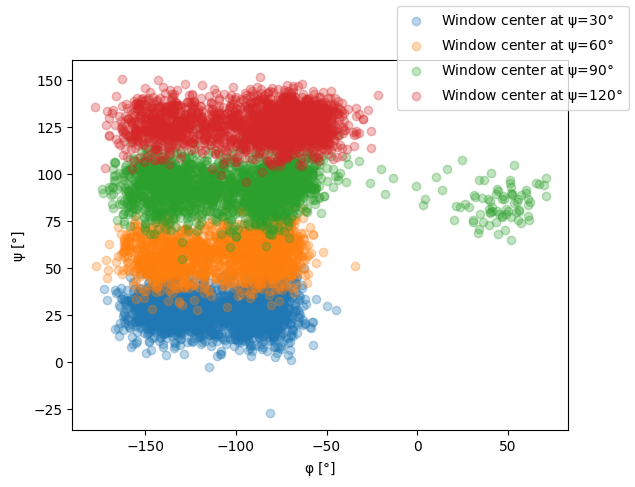

In [10]:
fig, axs = plt.subplots()

deg = 180/np.pi  # we want to plot in degree but psi_phi_wrapped is in radians
for wc, psi_phi_for_window in zip(window_centers, all_psi_phi_values):
    axs.scatter(y=np.concatenate(psi_phi_for_window, axis=0)[:, 0] * deg,
                x=np.concatenate(psi_phi_for_window, axis=0)[:, 1] * deg,
                label=f"Window center at ψ={wc}$\\degree$",
                alpha=0.3,
                )

axs.set_ylabel("ψ [$\\degree$]")
axs.set_xlabel("φ [$\\degree$]")
fig.legend();